<a href="https://colab.research.google.com/github/AlHartMos/IEU_courses/blob/main/simulating_and_modeling/Arrow_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arrow Shooting Simulation: From Simple to Complex Models

As we have seen in class, simulation models are abstractions of real-world phenomena. They allow us to analyze and predict behaviors. Here, we simulate the flight of an arrow, demonstrating both deterministic and stochastic aspects of modeling.

## Deterministic Models
A deterministic model predicts a unique outcome for a given set of inputs.

**Step 1: The Simplest Model – Straight-Line Motion**

Initially, we assume the arrow travels in a straight line, ignoring external forces like gravity. This represents the simplest abstraction.

Mathematical Model:

$$d = v \cdot t$$

Where:
- $d$: distance traveled (meters)
- $v$: velocity of the arrow (m/s)
- $t$: time of flight (seconds)

Here, the arrow moves at a constant velocity. This simplification assumes ideal conditions, such as no wind or gravity.

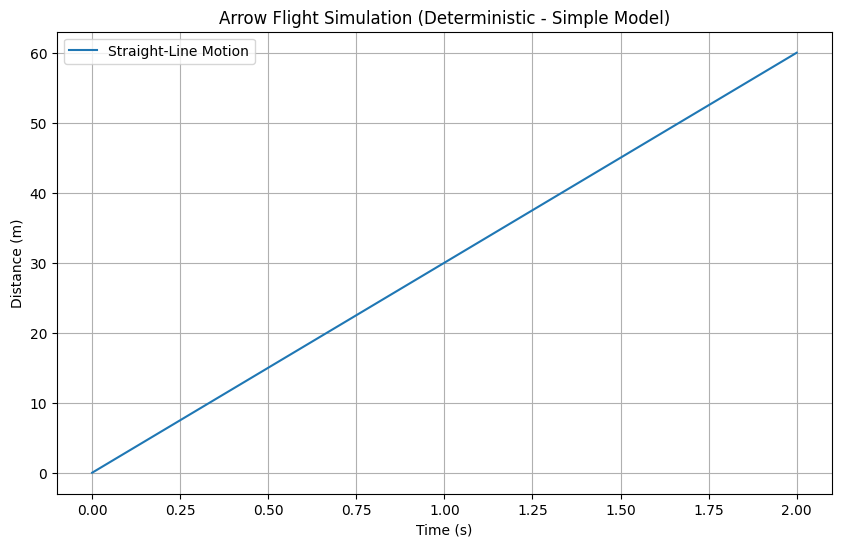

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
velocity = 30  # Arrow velocity in m/s
time = np.linspace(0, 2, 100)  # Time from 0 to 2 seconds
distance = velocity * time  # Distance traveled

# Plotting the motion
plt.figure(figsize=(10, 6))
plt.plot(time, distance, label="Straight-Line Motion")
plt.title("Arrow Flight Simulation (Deterministic - Simple Model)")
plt.xlabel("Time (s)")
plt.ylabel("Distance (m)")
plt.legend()
plt.grid()
plt.show()

This model provides a first approximation of the system. However, it lacks realism since it ignores critical physical forces like gravity and air resistance.

**Simple Models** are general but may oversimplify real-world phenomena. For example, a straight-line model for throwing a stone is quick and easy but fails for long distances.

**Complex Models** are detailed but harder to generalize and compute. For example, accounting for wind or air resistance increases realism but limits applicability to other scenarios.

**Step 2: Adding Gravity**

To improve realism, we include gravity. Gravity introduces a vertical acceleration, causing the arrow to follow a parabolic trajectory.

Mathematical Model: The arrow's motion is split into two components: horizontal ($x$) and vertical ($y$).

- Horizontal Motion:
$$x = v \cdot t \cdot cos(\theta)$$

- Vertical Motion:
$$ y = v \cdot t \cdot sin(\theta) - \frac{1}{2} gt^2 $$

Where:

- $\theta$: angle of launch (degrees)
- $g$: acceleration due to gravity ($9.8m/s^2$)

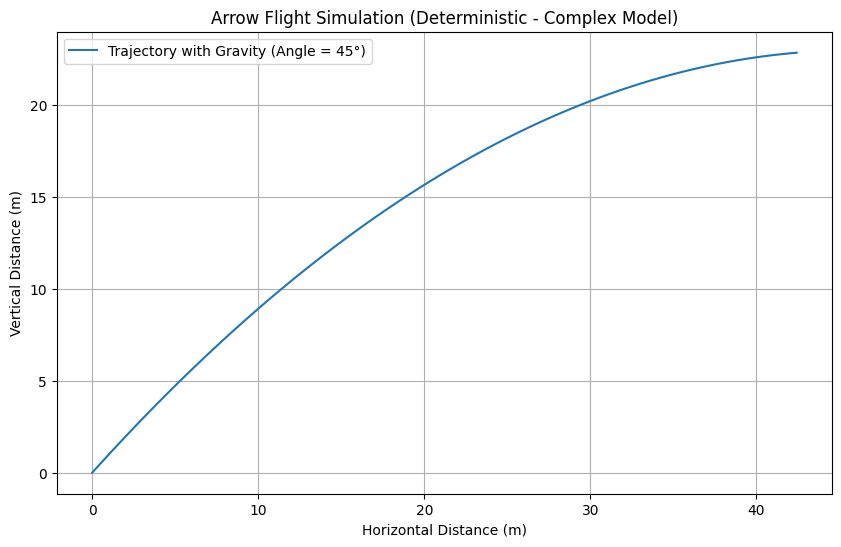

In [ ]:
# Parameters
angle = 45  # Launch angle in degrees
g = 9.8  # Gravity acceleration in m/s^2
theta = np.radians(angle)  # Convert angle to radians

# Position calculations
x = velocity * time * np.cos(theta)  # Horizontal distance
y = velocity * time * np.sin(theta) - 0.5 * g * time**2  # Vertical distance

# Filter valid points (y >= 0)
valid_indices = y >= 0
x, y = x[valid_indices], y[valid_indices]

# Plotting the trajectory
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f"Trajectory with Gravity (Angle = {angle}°)")
plt.title("Arrow Flight Simulation (Deterministic - Complex Model)")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.legend()
plt.grid()
plt.show()


This model improves fidelity by considering gravitational effects, making it more realistic. However, it remains deterministic: given the same inputs, it always produces the same trajectory.

## Stochastic Models

Deterministic models lack variability. Real-world systems often involve uncertainty, which is captured by stochastic models.

**Scenario: Modeling Archers with Variable Skill Levels**

Each archer has different skill levels, introducing variability in:
- Arrow velocity
- Launch angle

We model these as random variables using normal distributions:
- $v \sim N(30,5)$: Velocity with mean $30 m/s$ and standard deviation $5$.
- $\theta \sim N(45,10)$: Angle with mean $45°$ and standard deviation $10$.

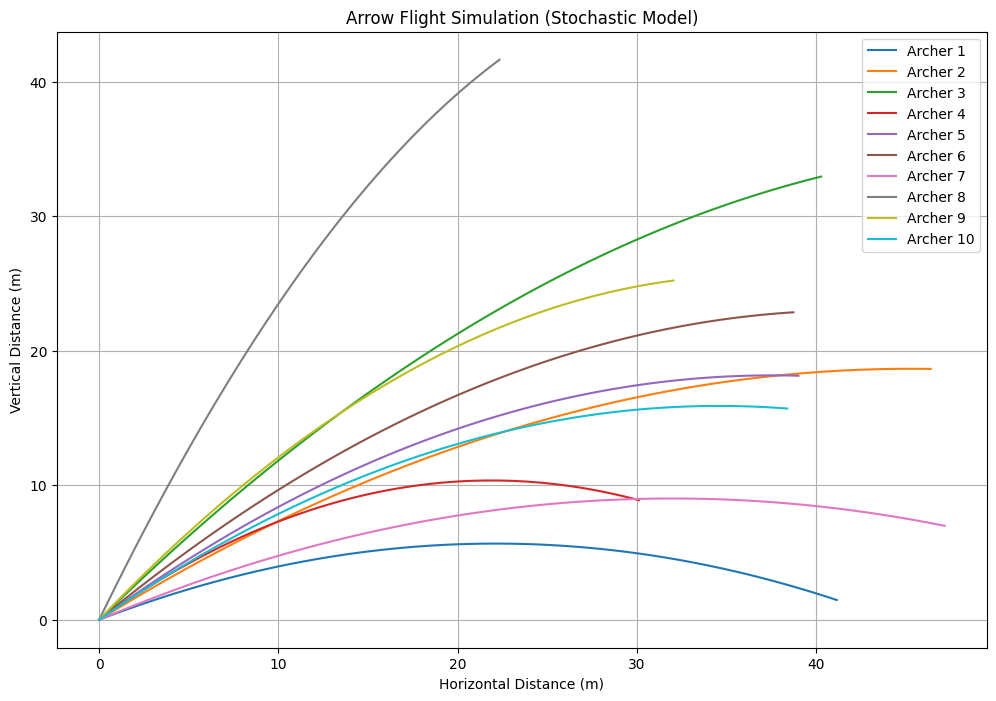

In [ ]:
# Parameters for stochastic simulation
archers = 10  # Number of archers
velocities = np.random.normal(30, 5, archers)  # Arrow velocities (m/s)
angles = np.random.normal(45, 10, archers)  # Launch angles (degrees)

# Plotting trajectories for multiple archers
plt.figure(figsize=(12, 8))
for i in range(archers):
    theta = np.radians(angles[i])  # Convert angle to radians
    x = velocities[i] * time * np.cos(theta)
    y = velocities[i] * time * np.sin(theta) - 0.5 * g * time**2
    valid_indices = y >= 0
    x, y = x[valid_indices], y[valid_indices]
    plt.plot(x, y, label=f"Archer {i+1}")

plt.title("Arrow Flight Simulation (Stochastic Model)")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.legend(loc="upper right")
plt.grid()
plt.show()


**Deterministic Models**: Provide consistent results given the same inputs. Useful for controlled environments.

**Stochastic Models**: Reflect real-world variability. Useful for understanding ranges of possible outcomes and uncertainty.